In [1]:
!pip install ~/fwiVis/utility_functions/
! pip install plotnine

Processing /home/jovyan/fwiVis/utility_functions
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fwiVis: filename=fwivis-0.1-py3-none-any.whl size=5594 sha256=962a51522e72922b1f6fa1dddb2d71e420bb1dd1e358a5da989c656b88b33db5
  Stored in directory: /tmp/pip-ephem-wheel-cache-v8wihdog/wheels/79/0f/3d/08c18473dd7e0fb915900e6b4f13b81f1fa84371f9bf24d864
Successfully built fwiVis
  Using cached plotnine-0.15.3-py3-none-any.whl.metadata (9.5 kB)
  Using cached mizani-0.14.4-py3-none-any.whl.metadata (4.8 kB)
Using cached plotnine-0.15.3-py3-none-any.whl (1.3 MB)
Using cached mizani-0.14.4-py3-none-any.whl (133 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotnine]1/2 [plotnine]


In [2]:
#import fwiVis.fwiVis as fv
import s3fs
s3 = s3fs.S3FileSystem(anon=False)
from math import cos, asin, sqrt
import re

import numpy as np
import geopandas as gpd
import pandas as pd
#from matplotlib import pyplot as plt
import os
import rioxarray as rio
import xarray as xr
import rasterio
import glob
from shapely.errors import ShapelyDeprecationWarning
from shapely.geometry import Point
import warnings
import folium
import datetime
import time
from folium import plugins
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
import contextily as cx
from shapely.geometry import box
import shapely
import sys
from datetime import datetime, timedelta
from itertools import chain
from datetime import date
import matplotlib.pyplot as plt
import statsmodels.api as sm


sys.path.insert(0, '/projects/old_shared/fire_weather_vis/base-fwi-vis/')
import fwiVis.fwiVis as fv

# Read in FEDS fire data 

In [3]:
fires_feds = fv.formatting_read_in('data/Quebec_v3_full_data_perimeters20241112.csv', start_time = '2023-05-31 00:00:00', end_time = '2023-09-15 12:00:00', gen_cols = False, merge_with_ciffc = False, merge_with_nbac = False)
fires_feds_max = fires_feds.groupby("fireID").farea.max()
fires = fv.formatting_read_in('data/Quebec_v3_full_data_perimeters20241112.csv', start_time = '2023-05-31 00:00:00', end_time = '2023-09-15 12:00:00', gen_cols = True, merge_with_ciffc = False, merge_with_nbac = True)
fires_allt = fires = fv.formatting_read_in('data/Quebec_v3_full_data_perimeters20241112.csv', start_time = '2023-05-31 00:00:00', end_time = '2023-09-15 12:00:00', gen_cols = True, merge_with_ciffc = False, merge_with_nbac = True)

fires = fires.to_crs(4326)


/srv/conda/envs/notebook/lib/python3.12/site-packages/fwiVis/fwiVis.py:206: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fire3 = fire3.groupby("fireID").apply(chop_fires_at_end).reset_index(drop = True)
/srv/conda/envs/notebook/lib/python3.12/site-packages/fwiVis/fwiVis.py:206: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fire3 = fire3.groupby("fireID").apply(chop_fires_at_end).reset_index(drop = True)
/srv/conda/e

# Read in the fire area from NBAC


In [4]:
nbac_only = gpd.read_file(f"{os.path.abspath('contextual_data')}/NBAC/nbac_2023_20240530.shp")

nbac_only = nbac_only[nbac_only.ADMIN_AREA == 'QC']
nbac_only  = nbac_only [(nbac_only.ADJ_HA >= 400) |(nbac_only.POLY_HA >= 400)]

# Drop all but final perimeter of FEDS, join with NBAC

In [5]:
fires = fires.to_crs(nbac_only.crs)

def get_max_area(df):
    df["unitless_area"] = df.geometry.area
    df = df[df.unitless_area == df.unitless_area.max()]
    return( df[df.t == df.t.max()])

fires = fires.groupby("fireID").apply(get_max_area).reset_index(drop = True)

fires = fires[['mergeid', 'ftype', 'n_pixels', 'n_newpixels', 'farea', 'fperim',
       'flinelen', 'duration', 'pixden', 'meanFRP', 't', 't_st', 't_ed',
       'fireID', 'isignition', 't_inactive', 'isactive', 'isdead',
       'mayreactivate', 'geom_counts', 'low_confidence_grouping', 'region',
       'primarykey', 'geometry']]

fires = fires.to_crs(nbac_only.crs)
nbac = nbac_only.sjoin(fires)
fires = fires.to_crs("4326")


nbac = nbac[(nbac.HS_SDATE < "2023-09-15" ) |  (nbac.AG_SDATE < "2023-09-15")]


print(len(nbac.NFIREID.unique())) ## Intersection.

print(len(nbac_only.NFIREID.unique())) ### 4 in NBAC not in FEDS
print(len(fires.fireID.unique())) ## Intersection





print(f"Per-fire Comparison of Area between Fire Events Suite (FEDS) data and Canadian National Burned Area Composite (NBAC) data. Red line shows 1:1 line.  FEDs tracked {len(fires_feds.fireID.unique())} fires total. NBAC tracked {len(nbac_only.NFIREID.unique())} fires total. {len(fires.fireID.unique())} of the FEDS perimeters overlapped with {len(nbac.NFIREID.unique())} of the NBAC perimeters. FEDS assigned fireIDs to {len(fires_feds.fireID.unique()) - len(fires.fireID.unique())} fires not found in the NBAC. Some were likely false positives associated with built infrastructure or water bodies. {len(nbac_only.NFIREID.unique()) - len(nbac.NFIREID.unique())} NBAC fires were not present in FEDS, ranging from {round(nbac_only[~nbac_only.NFIREID.isin(nbac.NFIREID.unique())].POLY_HA.min()/100, 2)} km^2 to {round(nbac_only[~nbac_only.NFIREID.isin(nbac.NFIREID.unique())].POLY_HA.max()/100, 2)} km^2. When multiple FEDS ids were associated with a single NBAC perimeters, fire areas were combined. In total, FEDS estimated {round(fires_feds_max.sum(), 2)} km^2 of fire affected area, and NBAC estimated {round(nbac_only.POLY_HA.sum()/100, 2)} km^2 burned area. Where they overlapped, FEDS estimated {round(nbac.groupby("fireID").farea.max().sum(), 2)} km^2 and NBAC {round(nbac.groupby("NFIREID").POLY_HA.max().sum()/100, 2)}.")

/tmp/ipykernel_2725/1801956632.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fires = fires.groupby("fireID").apply(get_max_area).reset_index(drop = True)


112
116
160
Per-fire Comparison of Area between Fire Events Suite (FEDS) data and Canadian National Burned Area Composite (NBAC) data. Red line shows 1:1 line.  FEDs tracked 170 fires total. NBAC tracked 116 fires total. 160 of the FEDS perimeters overlapped with 112 of the NBAC perimeters. FEDS assigned fireIDs to 10 fires not found in the NBAC. Some were likely false positives associated with built infrastructure or water bodies. 4 NBAC fires were not present in FEDS, ranging from 5.47 km^2 to 13.5 km^2. When multiple FEDS ids were associated with a single NBAC perimeters, fire areas were combined. In total, FEDS estimated 50129.46 km^2 of fire affected area, and NBAC estimated 42578.62 km^2 burned area. Where they overlapped, FEDS estimated 50072.47 km^2 and NBAC 42544.19.


# Describe Fires Appearing only in FEDS or only in NBAC

In [6]:
feds_only = fires[~fires.fireID.isin(nbac.fireID)]
print(len(feds_only.fireID.unique()))
print(feds_only.groupby("fireID").farea.max().mean())
#feds_only.explore()
## Small, short (1-4 time periods), and possibly tied to static sources and/or false positives. (2 Water bodies,  1 airport).
### 13 in feds, but not in NBAC

0
nan


In [7]:
nbac_o = nbac_only[~nbac_only.NFIREID.isin(nbac.NFIREID)]
print(len(nbac_o.NFIREID.unique()))
print(nbac_o.groupby("NFIREID").ADJ_HA.max().mean())
#nbac_o.explore() 
## 2 started late enough that it likely wasn't big enough for out analysis. Other 3  all small

4
860.6548700742501


# Plot fires with spatial overlap

This figure demponstrates that NBAC was more likely to "lump" together fires into one than FEDS. We handled this by adding together the areas of fires that had spatial intersection with an NBAC perimeter. 

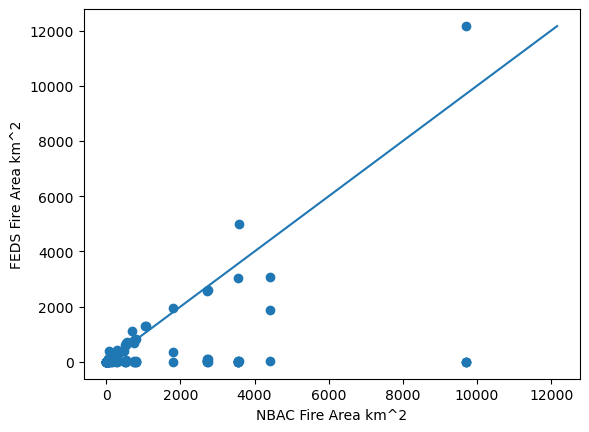

In [8]:
import matplotlib.pyplot as plt
import matplotlib
#matplotlib.rc('text', usetex = True)
seq = range(0, round(nbac.farea.max()), round((nbac.farea.max()/ len(nbac.farea))))

plt.scatter(x = nbac.ADJ_HA/100, y = nbac.farea)
plt.xlabel("NBAC Fire Area km^2")
plt.ylabel("FEDS Fire Area km^2")

plt.plot(seq, seq)

# Plot additive FEDS vs NBAC

/tmp/ipykernel_2725/435813894.py:56: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nbac_plot = nbac.groupby("NFIREID").apply(add_small_areas).reset_index(drop = True)


IDs where FEDS tracked multiple fires within one NBAC fire 0
R squared against the 1:1 0.9369934661603834
R quared against the line of best fit 0.9839268473692075


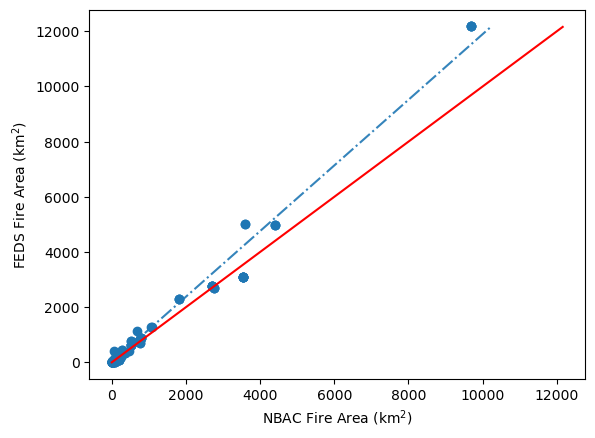

In [9]:
def r_squared_against_1to1_line(y_true, y_pred):
    """
    Calculate R² (coefficient of determination) against a 1:1 line.
    
    This measures how well the data fits the perfect agreement line (1:1 line)
    rather than against a best-fit regression line.
    
    Parameters:
    -----------
    y_true : array-like
        Ground truth (correct) values
    y_pred : array-like
        Predicted or test values to compare
        
    Returns:
    --------
    r_squared : float
        R² value against the 1:1 line. Values closer to 1 indicate better agreement.
        Can be negative if predictions are worse than using the mean as a predictor.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    # Total sum of squares (proportional to variance of the data)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    
    # Sum of squares of residuals from 1:1 line
    # For 1:1 line, the predicted value should equal the true value
    ss_res = np.sum((y_true - y_pred)**2)
    
    # R² calculation
    r_squared = 1 - (ss_res / ss_tot)
    
    return r_squared


def drop_small_areas(df):
    unique_feds_ids = df.fireID.unique()
    fmax = df.farea.max()
    ## Trying just max to prevent subbing the weird small fires
    fireID = df[df.farea == fmax].fireID.iloc[0]
    df = df[df.fireID == fireID]
    df["max_feds_area"] = df.farea.max()
    return(df)


def add_small_areas(df):
    unique_feds_ids = df.fireID.unique()
    max_fareas = []
    for i in unique_feds_ids:
        max_fareas.append(df[df.fireID == i].farea.max())
    df["sum_feds_area"] = np.sum(max_fareas)
    return(df)

                           
nbac_plot = nbac.groupby("NFIREID").apply(add_small_areas).reset_index(drop = True)

print(f'IDs where FEDS tracked multiple fires within one NBAC fire {len(nbac.fireID.unique()) - len(nbac_plot.fireID.unique())}')
seq = range(0, round(nbac_plot.farea.max()), round((nbac_plot.farea.max()/ len(nbac_plot.farea))))

plt.scatter(x = nbac_plot.ADJ_HA/100, y = nbac_plot.sum_feds_area)
r_sq = r_squared_against_1to1_line(nbac_plot.ADJ_HA/100, nbac_plot.sum_feds_area)


model = sm.OLS(endog = nbac_plot.ADJ_HA/100, exog = nbac_plot.sum_feds_area)
results = model.fit()
plt.plot(results.params.iloc[0] * seq, seq,  linestyle = "dashdot", alpha = 0.90)
print(f"R squared against the 1:1 {r_sq}")
print(f"R quared against the line of best fit {results.rsquared}")
plt.xlabel("NBAC Fire Area (km$^2$)")
plt.ylabel("FEDS Fire Area (km$^2$)")

plt.plot(seq, seq, color = "red")
plt.savefig(f'{os.path.abspath("some_figs/")}/NBAC_compare_plot.svg', dpi = 900, transparent = True)
plt.show()

# Check the outliers

In [10]:
def get_area_diff(df):
    unique_feds_ids = df.fireID.unique()
    ## Trying just max to prevent subbing the weird small fires
    df["area_source_diff"] = (df.ADJ_HA/100) - df.farea.max()
    return(df)

nbac = nbac.groupby("NFIREID").apply(get_area_diff).reset_index(drop = True)




plus_10_percent = (nbac.ADJ_HA/100) >= (nbac.farea * 1.1)
minus_10_percent = (nbac.ADJ_HA/100) <= (nbac.farea * 0.9)



bigger_ids = nbac[plus_10_percent].NFIREID.unique() ## 19 larger
print(f"The bigger IDS from NBAC are {bigger_ids}.")


nbac = nbac.sort_values(by = "area_source_diff")
bigger_nbac = nbac.groupby("NFIREID").area_source_diff.max().reset_index()
bigger_nbac = bigger_nbac.sort_values(by = "area_source_diff", ascending= False)


The bigger IDS from NBAC are [ 339.  340.  341.  345.  346.  347.  348.  468.  469.  477.  483.  489.
  491.  500.  504.  505.  508.  517.  521.  526.  530.  531.  533.  535.
  541.  542.  543.  544.  545.  546.  548.  550.  551.  553.  561.  562.
  563.  564.  565.  566.  567.  568.  577.  580. 2079.].


/tmp/ipykernel_2725/3842751129.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nbac = nbac.groupby("NFIREID").apply(get_area_diff).reset_index(drop = True)


# Looking at totals

In [11]:
print(f"Num fires tracked by feds {len(fires.fireID.unique())}")

tot_nbac = np.sum(nbac_only.ADJ_HA)/100


tot_feds = np.sum(fires.farea)

print(f"NBAC found {tot_nbac}km^2 total fire area. FEDS estimated {tot_feds}")

Num fires tracked by feds 160
NBAC found 42578.61586230361km^2 total fire area. FEDS estimated 50072.46504302653


# Generate text for the results section

In [12]:
biggest_fire = fires[fires.farea == fires.farea.max()].fireID.iloc[0]

In [13]:
print(f" The largest fire burned more than 1M ha over {round(fires[fires.fireID == biggest_fire].duration.max())} days ({round(fires[fires.fireID == biggest_fire].farea.iloc[0])} km^2),  in 2023,")
print(f"and the average final fire size and duration were {round(fires.farea.mean())} km^2 and {round(fires.duration.mean())} days.")

 The largest fire burned more than 1M ha over 78 days (12166 km^2),  in 2023,
and the average final fire size and duration were 313 km^2 and 15 days.


In [20]:
eco_provs_n = gpd.read_file(f'{os.path.abspath("contextual_data/")}/ecoregions/QC_NorthernEcoregions_LimitedResponseZone.shp')
eco_provs_s = gpd.read_file(f'{os.path.abspath("contextual_data/")}/ecoregions/QC_SouthernEcoregions_FullResponseZone.shp')
eco_provs_n = eco_provs_n.to_crs("4326")
eco_provs_s = eco_provs_s.to_crs("4326")
eco_provs_s['geometry'] = shapely.unary_union(eco_provs_s.geometry)
eco_provs_n['geometry'] = shapely.unary_union(eco_provs_n.geometry)
eco_provs_s.loc[:, 'suppression'] = "IPZ"
eco_provs_n.loc[:, 'suppression'] = "NPZ"
eco_provs = pd.concat([eco_provs_s, eco_provs_n])


fires_zones = fires.sjoin(eco_provs, how = "left")
print(len(fires_zones[~fires_zones.suppression.isna()].fireID.unique()))

print(f"Intensive Protection Zone in southern Quebec are actively suppressed and therefore smaller, on average ({round(fires_zones[fires_zones.suppression=='IPZ'].farea.mean())} km^2),")

print(f"whereas fires in the Northern Protection Zone may be monitored but allowed to burn or receive modified suppression to protect structures or critical infrastructure (On average {round(fires_zones[fires_zones.suppression=='NPZ'].farea.mean())} km^2).")
print(f"Additionally, fires in the Northern Protection Zone lasted longer and burned later into the season than fires in the Intensive Protection Zone, with a maximum duration of {round(fires_zones[fires_zones.suppression=='NPZ'].duration.max())} in the NPZ and {round(fires_zones[fires_zones.suppression=='IPZ'].duration.max())} in the IPZ.")



160
Intensive Protection Zone in southern Quebec are actively suppressed and therefore smaller, on average (258 km^2),
whereas fires in the Northern Protection Zone may be monitored but allowed to burn or receive modified suppression to protect structures or critical infrastructure (On average 371 km^2).
Additionally, fires in the Northern Protection Zone lasted longer and burned later into the season than fires in the Intensive Protection Zone, with a maximum duration of 78 in the NPZ and 38 in the IPZ.


In [22]:
print(round(fires_zones[fires_zones.suppression=='IPZ'].duration.max()))

print(round(fires_zones[fires_zones.suppression=='NPZ'].duration.max()))

38
78
